# Setup

![DDI_LM.png](DDI_LM.png)

# Experiments

In [3]:
import os
import warnings
import logging
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_curve, roc_curve


# Set thread limits before PyTorch import
os.environ.update({k: "1" for k in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"]})
import torch

from ddi_graph_neural_network.train_model import main
from ddi_graph_neural_network.config import Config, LossType
from report_utils import (
    plot_experiment_results,
    find_balanced_threshold,
    render_interactive_visualization,
    get_base_config,
    get_feature_experiment_config,
    compute_node_metrics,
    compile_embeddings,
    plot_pharma_class_error_rates,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
logging.basicConfig(level=logging.DEBUG, format="%(asctime)s - %(levelname)s - %(message)s")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_style("whitegrid")
sns.set_context("talk")


## Experiments on Loss Functions and Labels

This section describes how negative examples are constructed for training and the loss configurations evaluated.

Negatives for training

- Sampled negatives: unlabeled pairs (non‑positive edges) are sampled uniformly and treated as negatives for training. This approach assumes most unobserved pairs are true negatives but admits the risk of including unlabelled positives among sampled negatives.

- Observed (validated) negatives: use only the validated negative labels provided in the CRESCENDDI dataset. This produces a smaller negative set; to correct for class imbalance we compensate by weighting the loss rather than inflating the negative sample count.

- Upsampled negatives: augment the observed negatives by sampling with replacement so that the number of negative training examples matches the number of positive examples. This yields a balanced training set but changes the effective data distribution seen during training.

Experimental design

We evaluate combinations of three orthogonal design choices:

1. Loss function: either (a) plain binary cross‑entropy on logits (BCEWithLogitsLoss) or (b) a weighted binary cross‑entropy that scales the positive class contribution by a scalar multiplier.

2. Negative handling: whether negatives are upsampled to balance the training set or the original observed negatives are used.

3. Training negative selection: whether the training set uses only sampled negatives (i.e., sampled from the unlabeled pool) or explicitly uses the validated negatives (controlled by `use_only_sampled_negatives_in_train`).

Weighted binary cross‑entropy

We implement a weighted BCE to compensate for label imbalance. Let $p=\sigma(z)$ be the model probability (sigmoid of the logit $z$), $y\in\{0,1\}$ the true label, and $N_{pos},N_{neg}$ the counts of positive and negative examples used for training. We define a positive‑class scaling factor

$$
\alpha_{pos} = \mathrm{pos\_loss\_multiplier}\;\frac{N_{neg}}{N_{pos}},
$$

and set the negative weight to $\alpha_{neg}=1$. The per‑example weighted binary cross‑entropy is

$$
\mathcal{L}(p,y) = -\alpha_{pos}\,y\,\log p - \alpha_{neg}\,(1-y)\,\log(1-p).
$$

In PyTorch this behaviour is achieved by providing a `pos_weight` parameter to `BCEWithLogitsLoss` (equal to $\alpha_{pos}$ above), which multiplies the loss contribution of positive examples.

Focal loss (note)

The binary focal loss modifies cross‑entropy with a focusing term and is defined as

$$
\mathrm{FL}(p_t) = -\alpha\,(1-p_t)^{\gamma}\,\log(p_t),
$$

where $p_t$ is the model probability for the true class, $\alpha$ balances classes, and $\gamma\ge 0$ focuses training on hard examples. When $\gamma=0$ the focal loss reduces to a (possibly weighted) cross‑entropy. In our hyperparameter search the best focal parameter collapsed to $\gamma\approx 0$, so focal loss provided no empirical advantage over the weighted BCE in this task.

Summary of empirical finding

Across the tested combinations, preserving the empirical negative prevalence (using observed negatives) while compensating for imbalance via loss weighting produced the best generalisation (ROC and PR). Upsampling negatives to force class balance did not improve, and in some cases reduced, validation performance. The optimized positive multiplier used in our experiments was approximately $0.5$ (reported in the results tables and figures), consistent with the weighting rule above.

The following cells run the selected configurations and collect ROC and PR curves, reporting means and standard deviations when repetitions are used.

### Optimizing individual losses

In [ ]:
settings = [
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.BCEWithLogitsLoss,
        "pos_loss_multiplier": 1,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": True,
        "use_only_sampled_negatives_in_train": True,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": False,
    },
    {
        "loss_type": LossType.WeightedBCEWithLogitsLoss,
        "pos_loss_multiplier": 0.5,
        "upsample_negative_labels": False,
        "use_only_sampled_negatives_in_train": True,
    },
]


In [ ]:
import pandas as pd

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

train_setttings = [(2272, 27794), (0, 30066), (2272, 27794), (0, 30066), (2272, 0), (0, 2272)]
n_pos_train = 30066
train_setttings_df = pd.DataFrame(
    train_setttings, columns=["Observed Negatives in Train", "Sampled Negatives in Train"]
)
train_setttings_df["Observed Positives in Train"] = n_pos_train
train_setttings_df["Positive Loss Multiplier"] = [r["pos_loss_multiplier"] for r in settings]
train_setttings_df["Loss Function"] = [str(r["loss_type"]).split(".")[-1] for r in settings]
train_setttings_df["Weight Factor Negative Loss"] = n_pos_train / (
    (train_setttings_df["Observed Negatives in Train"] + train_setttings_df["Sampled Negatives in Train"])
    * train_setttings_df["Positive Loss Multiplier"]
)
train_setttings_df = train_setttings_df[
    [
        "Loss Function",
        "Observed Positives in Train",
        "Observed Negatives in Train",
        "Sampled Negatives in Train",
        "Weight Factor Negative Loss",
    ]
]
train_setttings_df.index = [f"S{i + 1}" for i in range(len(train_setttings_df))]
train_setttings_df

# display as markdown
from IPython.display import Markdown, display

md = train_setttings_df.to_markdown()
display(Markdown("### Training Set Configurations\n\n" + md))


### Training Set Configurations

|    | Loss Function             |   Observed Positives in Train |   Observed Negatives in Train |   Sampled Negatives in Train |   Weight Factor Negative Loss |
|:---|:--------------------------|------------------------------:|------------------------------:|-----------------------------:|------------------------------:|
| S1 | BCEWithLogitsLoss         |                         30066 |                          2272 |                        27794 |                        1      |
| S2 | BCEWithLogitsLoss         |                         30066 |                             0 |                        30066 |                        1      |
| S3 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                        27794 |                        2      |
| S4 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                        30066 |                        2      |
| S5 | WeightedBCEWithLogitsLoss |                         30066 |                          2272 |                            0 |                       26.4665 |
| S6 | WeightedBCEWithLogitsLoss |                         30066 |                             0 |                         2272 |                       26.4665 |

In [ ]:
results_list = []
for i, setting in enumerate(settings):
    # Fetch a fresh base config for each run to avoid side-effects
    config = get_base_config()
    config.run.loss_type = setting["loss_type"]
    config.run.pos_loss_multiplier = setting["pos_loss_multiplier"]
    config.run.upsample_negative_labels = setting.get("upsample_negative_labels", False)
    config.run.use_only_sampled_negatives_in_train = setting.get("use_only_sampled_negatives_in_train", False)

    name = f"{setting['loss_type'].name}|mult={setting['pos_loss_multiplier']}|ups={setting.get('upsample_negative_labels', False)}|only_sampled={setting.get('use_only_sampled_negatives_in_train', False)}|reps={config.training.repetitions}"
    print(f"=== Running [{i + 1}/{len(settings)}]: {name} ===")

    run = main(config)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    results_list.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

settings_results = results_list

2026-04-20 17:10:55,710 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


=== Running [1/6]: BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1 ===


2026-04-20 17:10:58,507 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 17:10:58,579 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 17:10:58,581 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003


======== DESC_GPT ========


2026-04-20 17:10:58,782 - DEBUG - Sampling 27794 negative edges to add to training data.
2026-04-20 17:10:58,786 - DEBUG - After upsampling, training data has 30066 positive and 30066 negative samples.


KeyboardInterrupt: 

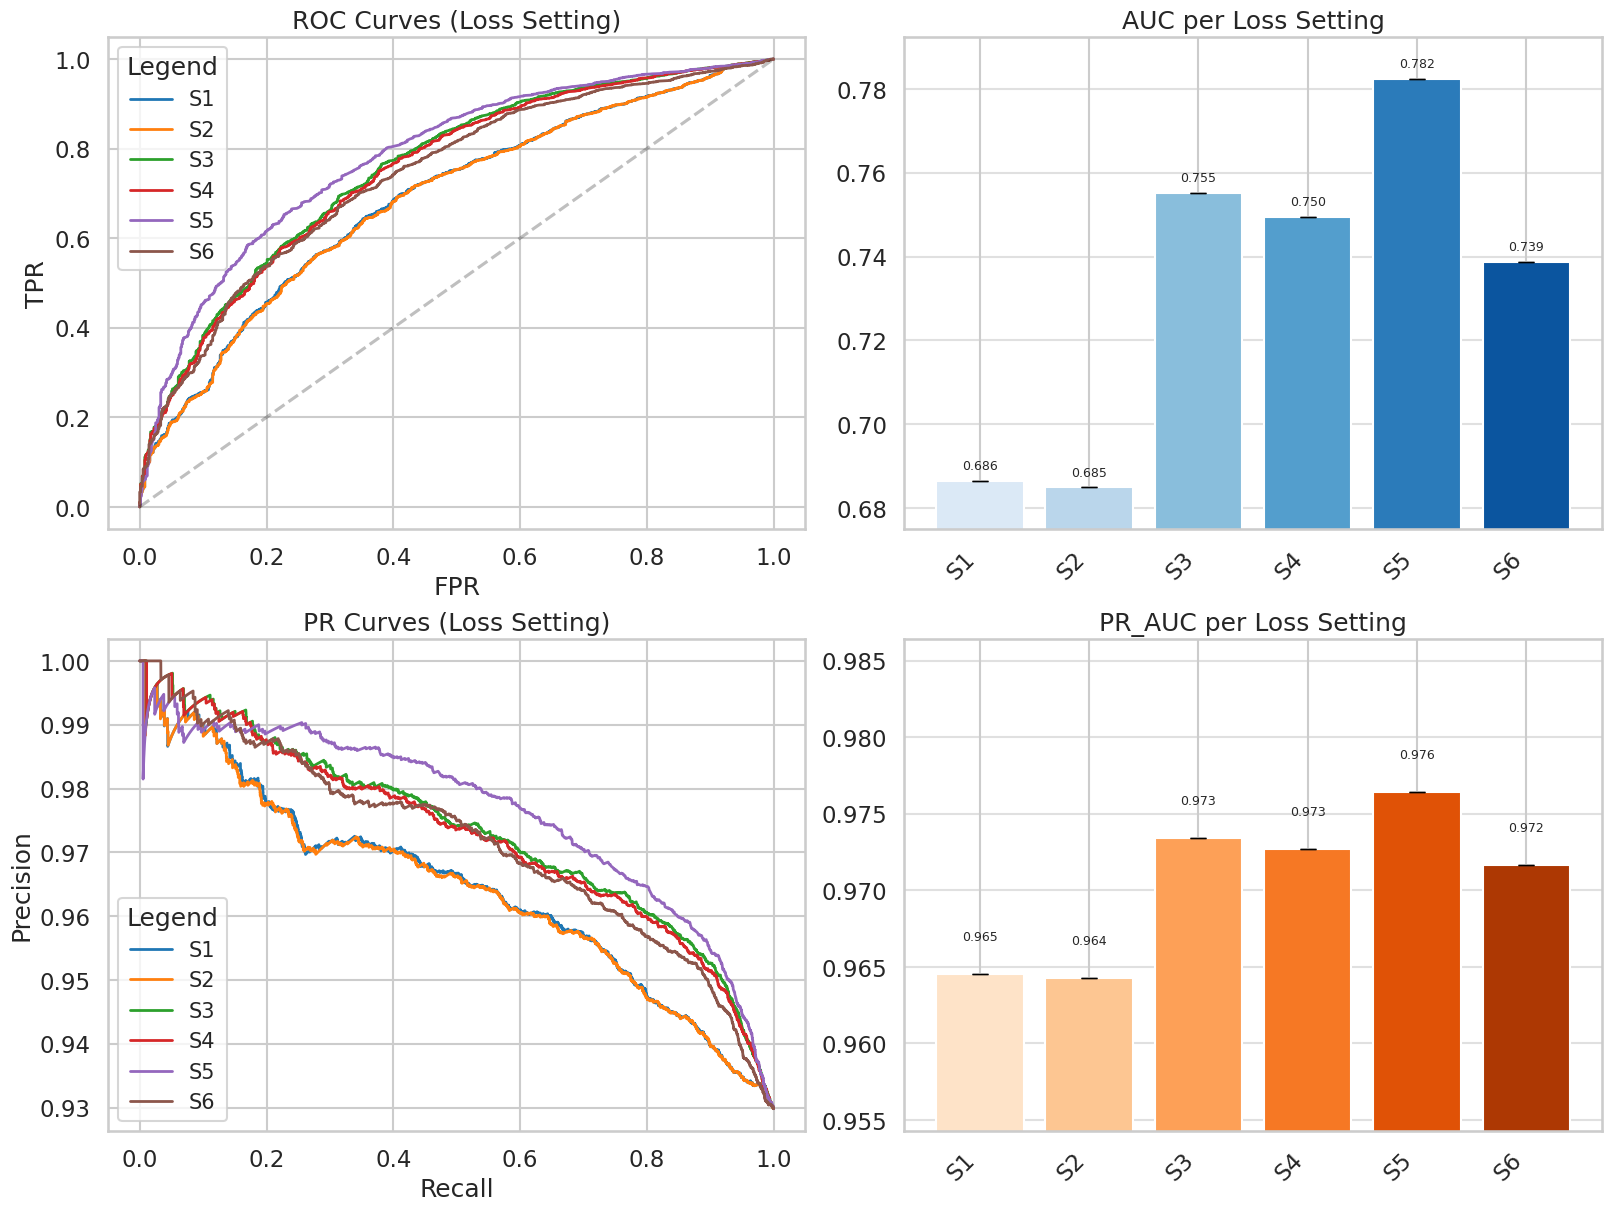

### Summary of Metrics (Loss Setting)

|    | short   | name                                                                   |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|---:|:--------|:-----------------------------------------------------------------------|-----------:|----------:|--------------:|-------------:|
|  0 | S1      | BCEWithLogitsLoss|mult=1|ups=True|only_sampled=False|reps=1            |   0.686494 |         0 |      0.96456  |            0 |
|  1 | S2      | BCEWithLogitsLoss|mult=1|ups=True|only_sampled=True|reps=1             |   0.684963 |         0 |      0.96428  |            0 |
|  2 | S3      | WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=False|reps=1  |   0.755235 |         0 |      0.973413 |            0 |
|  3 | S4      | WeightedBCEWithLogitsLoss|mult=0.5|ups=True|only_sampled=True|reps=1   |   0.74951  |         0 |      0.972702 |            0 |
|  4 | S5      | WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=False|reps=1 |   0.782446 |         0 |      0.976445 |            0 |
|  5 | S6      | WeightedBCEWithLogitsLoss|mult=0.5|ups=False|only_sampled=True|reps=1  |   0.738674 |         0 |      0.971664 |            0 |

In [18]:
# Generate plots and metrics output for the Loss Settings
plot_experiment_results(settings_results, title_suffix="Loss Setting", filename="report_grid.png")

Outcome:

- Switchting from BCE to Weighted improves performance with a near optimal factor of pos_loss_multiplier = 0.5

- using the true observed negative labels as learning signal improves performance to the pendent where this nubmer is sampled.
- The setting where only the true observed negatives are used and the class imbalance is tackled via the weighted loss function performs clearly the best. this indicates that the true negatives indeed deliver a stronger learning signal.


## Experiment of Embeddings

In [ ]:
feature_settings = [
    {
        "feature": "__ONES__",
    },
    {
        "feature": "DESC_GPT",
    },
]

In [ ]:
feature_results = []
for i, setting in enumerate(feature_settings):
    feature = setting.get("feature")
    # Use the isolated config definition for feature evaluation
    config_feature = get_feature_experiment_config()
    config_feature.graph.feature = feature

    name = f"Feature|{feature}"
    print(f"=== Running [{i + 1}/{len(feature_settings)}]: {name} ===")

    run = main(config_feature)
    y_true, y_scores = np.asarray(run["label"]), np.asarray(run["test_scores"])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    fpr, tpr, _ = roc_curve(y_true, y_scores)

    feature_results.append(
        {"name": name, "metrics": run["metrics"], "precision": precision, "recall": recall, "fpr": fpr, "tpr": tpr}
    )

2026-04-20 17:16:10,129 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI
2026-04-20 17:16:10,322 - DEBUG - Final graph has 1539 nodes and 54892 edges.
Positive edges: 51108, 
Negative edges: 3784
2026-04-20 17:16:10,323 - DEBUG - Run 1/1 for __ONES__ | LR: 0.0003


=== Running [1/2]: Feature|__ONES__ ===
======== __ONES__ ========


2026-04-20 17:16:10,345 - DEBUG - Using imbalanced loss with pos_weight: 0.0370
2026-04-20 17:16:36,407 - DEBUG - Early stopping at epoch 17
2026-04-20 17:16:37,154 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE __ONES__ -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.6597
PR_AUC: 0.9611
=== Running [2/2]: Feature|DESC_GPT ===


2026-04-20 17:16:39,938 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-20 17:16:40,011 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-20 17:16:40,013 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-20 17:16:40,043 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-20 17:17:14,459 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


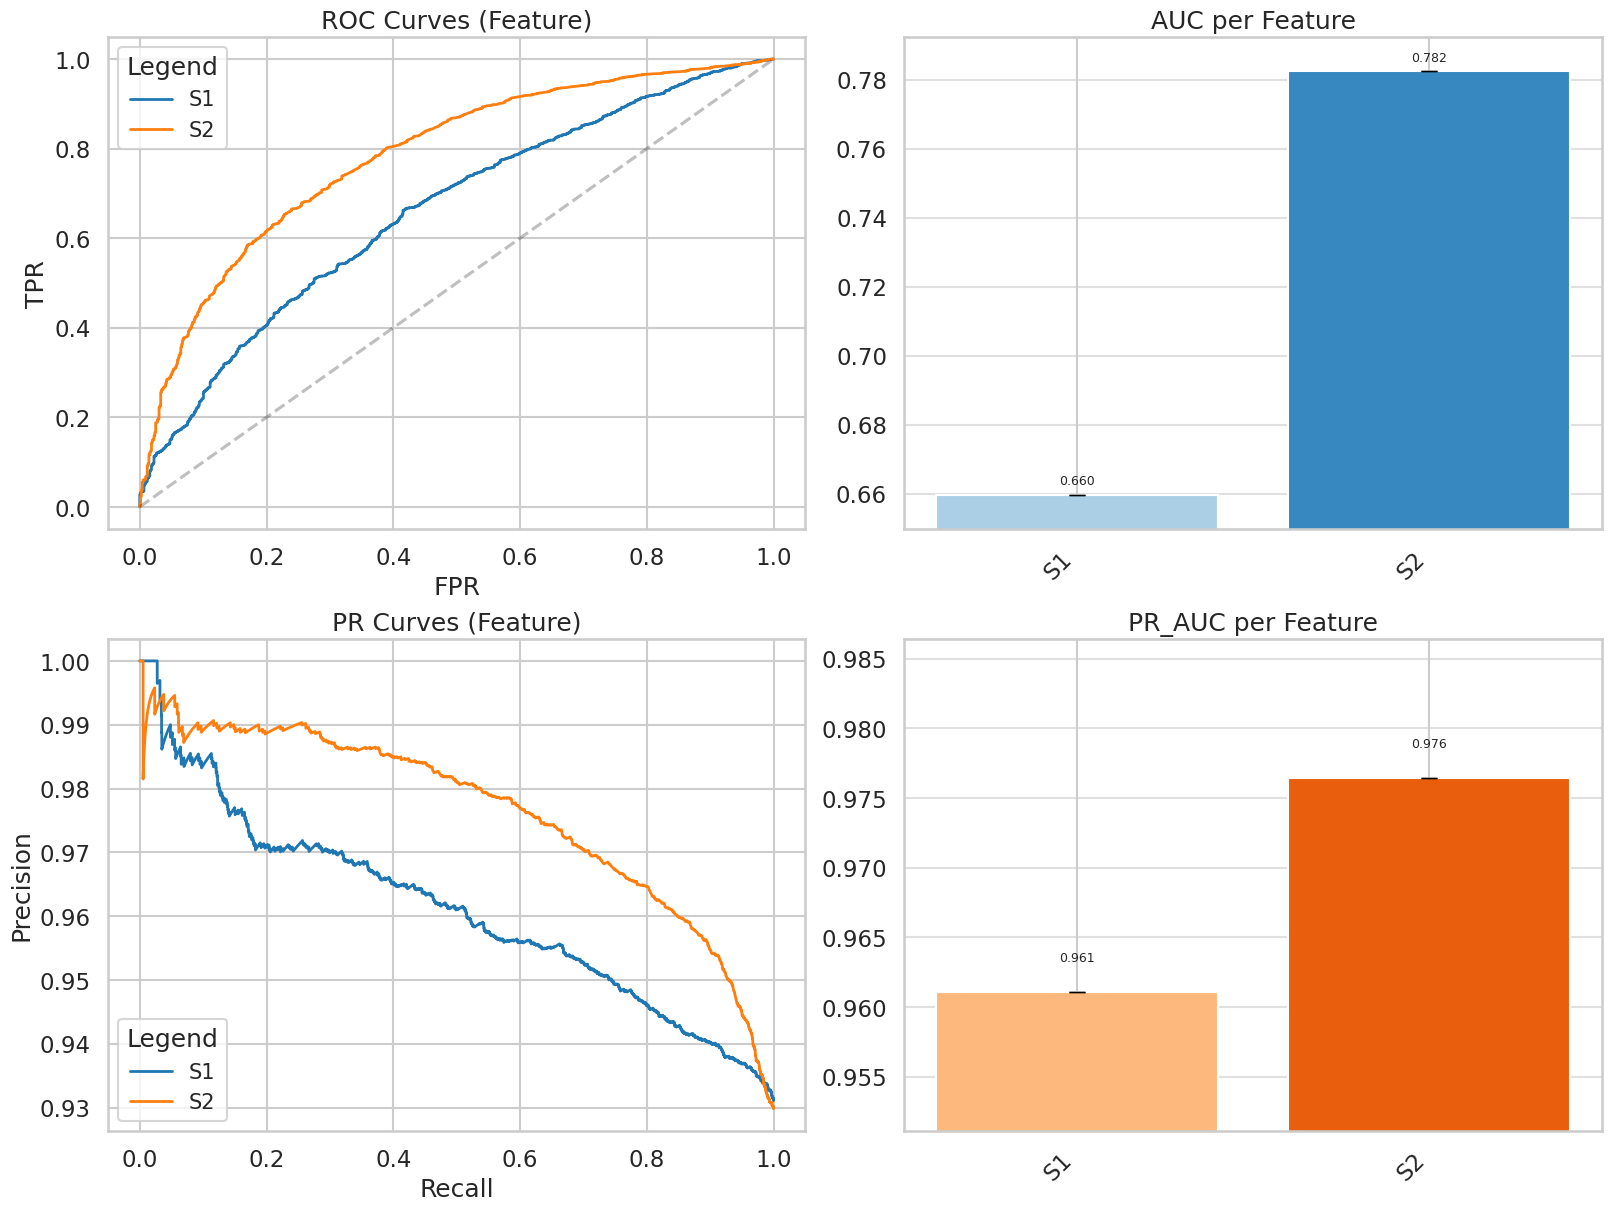

### Summary of Metrics (Feature)

|    | short   | name             |   AUC_mean |   AUC_std |   PR_AUC_mean |   PR_AUC_std |
|---:|:--------|:-----------------|-----------:|----------:|--------------:|-------------:|
|  0 | S1      | Feature|__ONES__ |   0.659729 |         0 |      0.961097 |            0 |
|  1 | S2      | Feature|DESC_GPT |   0.782446 |         0 |      0.976445 |            0 |

In [32]:
# Generate plots and metrics output for the Embeddings Settings
plot_experiment_results(feature_results, title_suffix="Feature", filename="report_grid_features.png")

- Strong learning signal by using description embedding of drugs using the GPT model.

## Analysis of trained model

In the following section, we analyze our model's performance in its optimal configuration, employing GPT-3 embeddings of drug descriptions combined with weighted binary cross-entropy loss (weight factor on negative loss = 26.4665) and no upsampling of negative labels. To ensure fair comparison across experimental settings, we calibrate the prediction threshold such that the number of predicted positive and negative labels are balanced.

Description embeddings prove to be a critical learning signal, yielding substantial improvements in model performance: the ROC-AUC increases from 0.66 to 0.78, and the PR-AUC improves from 0.96 to 0.98 compared to the baseline with constant node features. To elucidate the mechanisms underlying this improvement, we conducted a series of exploratory analyses presented below. Further ablation studies are required to fully characterize the contributions of individual components and to validate the statistical significance of our findings.

torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [4]:
config_analysis = get_feature_experiment_config()
config_analysis.graph.feature = "DESC_GPT"

In [ ]:
# Run the model using the analysis config
run = main(config_analysis)

# Unpack run results
test_data, test_scores, data, model = run["test_data"], run["test_scores"], run["data"], run["model"]
reversed_node_id_map = {v: k for k, v in run["node_id_map"].items()}

2026-04-24 16:43:53,705 - DEBUG - Loading CSV graph: DrugBank_CRESCENDDI


2026-04-24 16:43:57,862 - DEBUG - Graph and Embeddings Intersection Summary:
Number of drugs in graph: 1516, 
Number of embedding drugs in graph: 1516, 
Number of drugs dropped from graph (not in embeddings): 23, 
Number of embedding drugs not in graph: 7207
Kept percentage of embedding drugs not in graph: 0.0%, 

2026-04-24 16:43:58,003 - DEBUG - Final graph has 1516 nodes and 53892 edges.
Positive edges: 50108, 
Negative edges: 3784
2026-04-24 16:43:58,009 - DEBUG - Run 1/1 for DESC_GPT | LR: 0.0003
2026-04-24 16:43:58,122 - DEBUG - Using imbalanced loss with pos_weight: 0.0378


======== DESC_GPT ========


2026-04-24 16:44:16,159 - DEBUG - Early stopping at epoch 26


-------------------------------
-- FINAL RESULTS FOR GRAPH DrugBank_CRESCENDDI | FEATURE DESC_GPT -- 
Graph Data:  DrugBank_CRESCENDDI
ROC_AUC: 0.7824
PR_AUC: 0.9764


In [6]:
# Compute threshold and mapped predictions, and aggregate classification counts across all connected edges per source
threshold, node_info_trained = compute_node_metrics(test_data, test_scores, reversed_node_id_map)

print(f"Threshold: {threshold:.4f} | Negatives: {node_info_trained['FN'].sum() + node_info_trained['TN'].sum()}")
display(node_info_trained.head())

Threshold: 0.5001 | Negatives: 10760


,TP,TN,FP,FN,count,perc_missclassified,perc_neg_gt,balanced_error_rate
source,,,,,,,,
DB00005,3,0,0,0,3,0.0000,0.0000,0.0000
DB00006,0,0,0,6,6,100.0000,0.0000,0.5000
DB00007,29,0,0,11,40,27.5000,0.0000,0.1375
DB00008,1,0,0,2,3,66.6667,0.0000,0.3333
DB00009,0,3,0,21,24,87.5000,12.5000,0.5000


In [7]:
# Extract spatial and feature embeddings, resolve ATC classes and compile into a single dataframe
embedding = compile_embeddings(model, data, reversed_node_id_map, node_info_trained)
display(embedding.head(3))

,TSNE-1_input,TSNE-2_input,TSNE-1_latent,TSNE-2_latent,Drug Name,Discription,Description_Masked,drug_unique_count,drug_count,pharma_class,drug_name,atc_match,atc_class_lvl_1,perc_missclassified,balanced_error_rate,edge_count,perc_neg_gt
DB00005,25.9718,-41.9601,-14.8457,32.5630,Etanercept,Dimeric fusion protein consisting of the extra...,Dimeric fusion protein consisting of the extra...,2,3,0,etanercept,Etanercept,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,0.0000,0.0000,3.0000,0.0000
DB00006,0.8356,-38.4793,22.3275,39.4165,Bivalirudin,Bivalirudin is a synthetic 20 residue peptide ...,<DRUG> is a synthetic 20 residue peptide (<DRU...,2,4,1,bivalirudin,Bivalirudin,BLOOD AND BLOOD FORMING ORGAN DRUGS,100.0000,0.5000,6.0000,0.0000
DB00007,50.0014,46.9400,50.2005,-11.6888,Leuprolide,Leuprolide is a synthetic 9-residue peptide an...,<DRUG> is a synthetic 9-residue peptide analog...,1,4,2,leuprolide,NaN,NaN,27.5000,0.1375,40.0000,0.0000


,class,n,median,IQR,mean,std
9,NERVOUS SYSTEM DRUGS,248,29.4093,38.3356,38.5599,32.9028
2,ANTINEOPLASTIC AND IMMUNOMODULATING AGENTS,177,64.7059,66.6667,64.2071,34.2902
13,Unknown,176,90.2778,66.6667,67.2695,38.4224
0,ALIMENTARY TRACT AND METABOLISM DRUGS,163,82.7586,57.7381,68.8032,33.6697
5,CARDIOVASCULAR SYSTEM DRUGS,162,61.8056,63.9388,60.6399,31.5134
1,ANTIINFECTIVES FOR SYSTEMIC USE,152,88.8889,58.7500,71.8585,33.0236
11,SENSORY ORGAN DRUGS,115,71.4286,58.2011,64.3044,32.8076
10,RESPIRATORY SYSTEM DRUGS,104,21.5251,62.7493,36.5128,36.8971
6,DERMATOLOGICALS,90,66.6667,66.2162,64.7818,34.1525
7,GENITO URINARY SYSTEM AND SEX HORMONES,79,85.7143,57.7778,71.0995,31.8836


2026-04-24 16:45:25,576 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-24 16:45:25,579 - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-04-24 16:45:25,586 - DEBUG - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=18.0.
2026-04-24 16:45:25,588 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\c438731\\VSCProjects\\DDI_with_ML\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2026-04-24 16:45:25,589 - DEBUG - findfont: score(FontEntry(fname='c:\\Users\\c438731\\VSCProjects\\DDI_with_ML\\.venv\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizOneSymBol.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-04-24 16:45:25,590 - DEBU

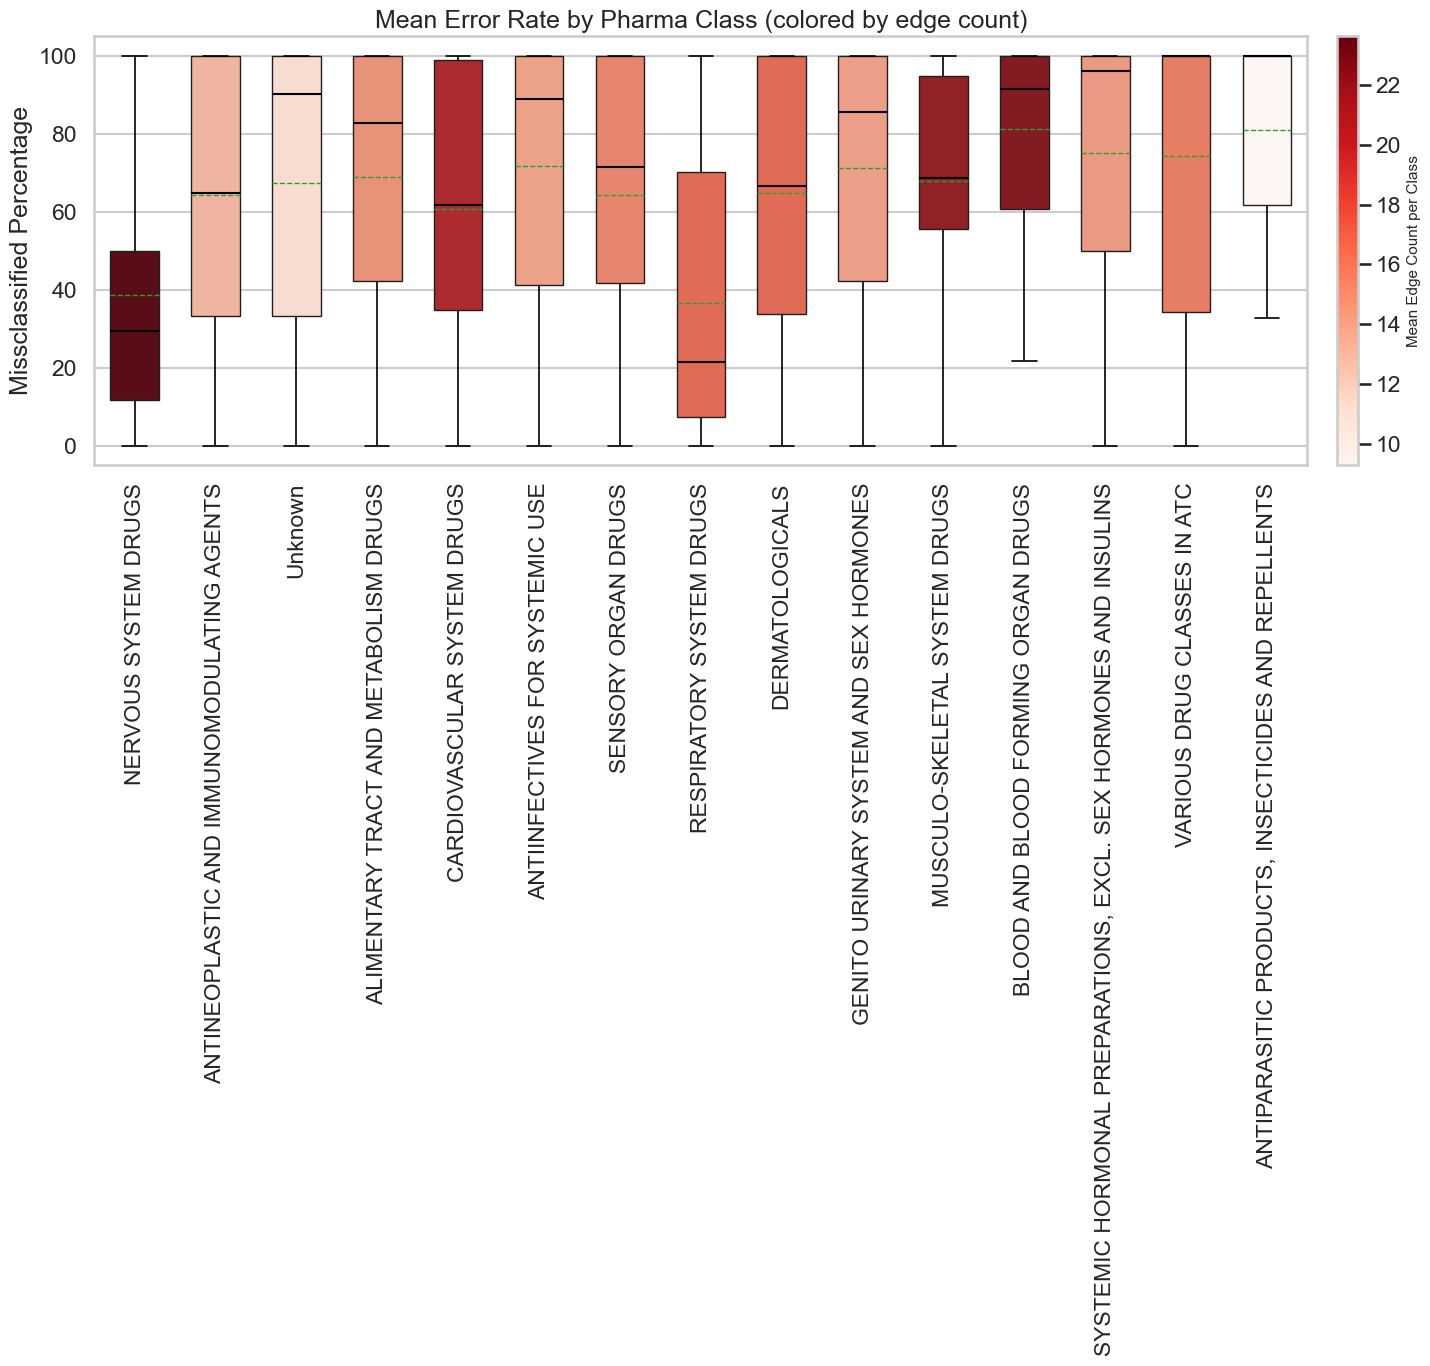

In [8]:
# Summarize error rates by Pharma Class and plot distribution using a Seaborn boxplot
plot_pharma_class_error_rates(embedding)

The per-class misclassification rates across ATC drug classifications reveal interesting performance variations among therapeutic categories. Our analysis presents the median (black), mean (green), and interquartile range of misclassification rates for each ATC class. The visualization shows that drugs targeting the nervous system and respiratory system exhibit notably lower misclassification rates compared to other therapeutic categories. This observation raises an important question about the underlying causes: are these lower error rates inherent to the chemical nature of drug interactions within these classes, or do they result from differences in dataset composition—such as the number of drugs per class, the density of edges, or the distribution of negative labels?

To address this question, we propose several approaches. First, suitable statistical tests could be applied, or the data could be normalized across classes to account for potential sampling biases. Second, since drug class information is implicitly encoded within the drug description embeddings used as node features, it is worth investigating whether these ATC classes constitute an important learning signal for the graph neural network. To evaluate this hypothesis, we suggest replacing the description embeddings with explicit ATC class features and comparing the model's performance. This substitution would allow us to isolate the contribution of class-level information to the model's predictive capacity. Additionally, similar analyses conducted on simpler baseline models would help establish the statistical significance of these findings and whether the observed effects are specific to the graph neural network architecture.

### Visualizations

To elucidate what structural information the model learns from drug descriptions—and how this contributes to its improved predictive performance—we examine the learned representations through a two-dimensional t-SNE projection of embeddings from the test set. We compare two feature spaces: (1) the input space derived directly from drug descriptions using GPT-3 embeddings, and (2) the latent space learned by the graph convolutional network trained on these embeddings. In both projections, clustering patterns are predominantly driven by ATC drug class membership, indicating that therapeutic classification encodes meaningful chemical and biological similarities that inform drug interaction prediction.

The interactive visualization enables detailed exploration of individual drugs and their predicted interactions. By selecting a drug of interest from the dropdown menu, users can examine all edges linking to that drug in the test set, with each edge color-coded according to its classification outcome (true positive, false positive, false negative, or true negative). The visualization further allows filtering by ATC class and edge type, facilitating targeted analysis of model performance across different therapeutic categories.

Each data point in the plot is accompanied by comprehensive metadata, including the drug name, DrugBank identifier, ATC classification, t-SNE coordinates, and the full description text used to generate the initial embeddings. This integrated view supports both qualitative inspection of individual cases and systematic exploration of systematic patterns in model predictions.


In [10]:
# ===== INTERACTIVE VISUALIZATION =====
render_interactive_visualization(embedding, test_data, test_scores, threshold, reversed_node_id_map)

# Discussion

# Open Points